# kNN Classification for Breast Cancer Diagnosis

**Author:** Dhruvika  
**Model:** k-Nearest Neighbors

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     cross_val_predict, StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay)

np.set_printoptions(precision=3, suppress=True)

## 1. Load the Data

In [2]:
df = pd.read_excel('wdbc_with_headers.xlsx')
df['diagnosis_binary'] = df['Diagnosis'].map({'M': 1, 'B': 0})

feature_cols = [c for c in df.columns if c not in ['ID', 'Diagnosis', 'diagnosis_binary']]
X = df[feature_cols].values
y = df['diagnosis_binary'].values

print(f'Dataset shape: {df.shape}')
print(f'Number of features: {len(feature_cols)}')
print(f'Missing values: {df.isnull().sum().sum()}')

Dataset shape: (569, 33)
Number of features: 30
Missing values: 0


## 2. Exploratory Data Analysis

In [3]:
# Class distribution — critical for interpreting accuracy later
class_counts = df['Diagnosis'].value_counts()
print('Class distribution:')
print(f'  Benign (B):    {class_counts["B"]} ({class_counts["B"]/len(df)*100:.1f}%)')
print(f'  Malignant (M): {class_counts["M"]} ({class_counts["M"]/len(df)*100:.1f}%)')

# Baseline: a naive model that always predicts the majority class (benign)
baseline_acc = class_counts.max() / len(df)
print(f'\nBaseline accuracy (predict "benign" always): {baseline_acc:.3f}')
print('Any useful model must beat this baseline meaningfully.')

Class distribution:
  Benign (B):    357 (62.7%)
  Malignant (M): 212 (37.3%)

Baseline accuracy (predict "benign" always): 0.627
Any useful model must beat this baseline meaningfully.


In [4]:
# Summary stats for a few key features
key_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
                'concavity_mean', 'concave_points_mean']
df[key_features].describe().round(2)

,radius_mean,texture_mean,perimeter_mean,area_mean,concavity_mean,concave_points_mean
count,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.09,0.05
std,3.52,4.30,24.30,351.91,0.08,0.04
min,6.98,9.71,43.79,143.50,0.00,0.00
25%,11.70,16.17,75.17,420.30,0.03,0.02
50%,13.37,18.84,86.24,551.10,0.06,0.03
75%,15.78,21.80,104.10,782.70,0.13,0.07
max,28.11,39.28,188.50,2501.00,0.43,0.20


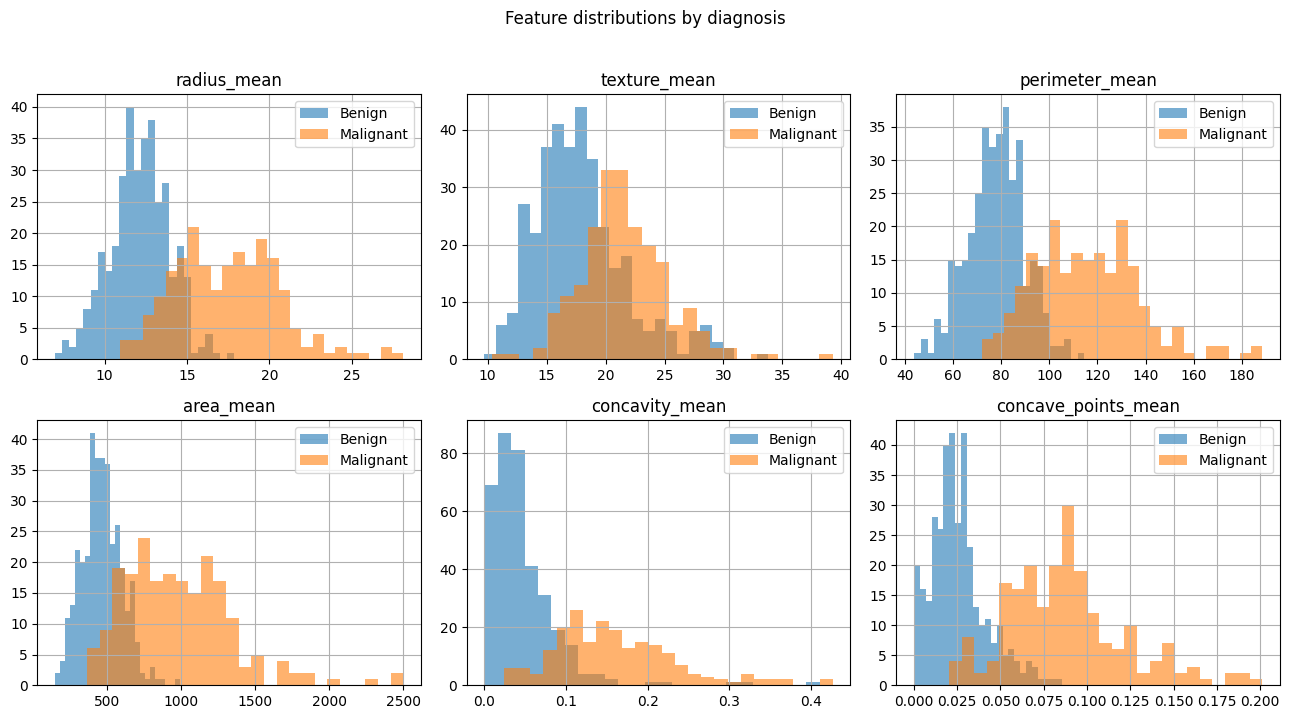

In [5]:
# Distributions of key features, split by diagnosis
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, feat in zip(axes.ravel(), key_features):
    df[df['Diagnosis']=='B'][feat].hist(ax=ax, alpha=0.6, label='Benign', bins=25)
    df[df['Diagnosis']=='M'][feat].hist(ax=ax, alpha=0.6, label='Malignant', bins=25)
    ax.set_title(feat)
    ax.legend()
plt.suptitle('Feature distributions by diagnosis', y=1.02)
plt.tight_layout()
plt.show()

**EDA takeaway:** malignant tumors tend to be larger and more irregular across every feature shown. There's substantial visual separation between classes, which is a good sign that a classifier should work well. The 63/37 class imbalance is mild — accuracy is still a reasonable metric, but we'll also report precision, recall, and F1.

## 3. Stratified 80/20 Train-Test Split



In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y)

print(f'Training set: {X_train.shape[0]} tumors  '
      f'({np.mean(y_train==0)*100:.1f}% benign, {np.mean(y_train==1)*100:.1f}% malignant)')
print(f'Test set:     {X_test.shape[0]} tumors  '
      f'({np.mean(y_test==0)*100:.1f}% benign, {np.mean(y_test==1)*100:.1f}% malignant)')
print('\nX_test and y_test will not be used in this notebook.')

Training set: 455 tumors  (62.6% benign, 37.4% malignant)
Test set:     114 tumors  (63.2% benign, 36.8% malignant)

X_test and y_test will not be used in this notebook.


## 4. Pipeline + Cross-Validated Hyperparameter Search

We wrap the scaler and kNN model in a `Pipeline` so that standardization happens **inside** each CV fold. This is important: if we scaled the whole training set once and then did CV, each fold's validation portion would have contaminated its training portion's scaler. The pipeline prevents this leakage.

**Hyperparameters searched** 
- `n_neighbors` (k): 1 to 30 — spans overfit-to-underfit regimes
- `weights`: `'uniform'` or `'distance'` — whether closer neighbors count more
- `metric`: `'euclidean'` or `'manhattan'` — from §5 notes: kNN's `k, choice of metric`

**Total combinations:** 30 × 2 × 2 = 120, each evaluated by 5-fold CV → 600 model fits.

In [8]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': list(range(1, 31)),
    'knn__weights':     ['uniform', 'distance'],
    'knn__metric':      ['euclidean', 'manhattan']
}

grid = GridSearchCV(
    pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid.fit(X_train, y_train)

print(f'Best hyperparameters: {grid.best_params_}')
print(f'Best 5-fold CV accuracy: {grid.best_score_:.4f}')

Best hyperparameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'knn__weights': 'uniform'}
Best 5-fold CV accuracy: 0.9692


### Top-10 hyperparameter combinations

In [9]:
cv_results = pd.DataFrame(grid.cv_results_)
top10 = cv_results.nlargest(10, 'mean_test_score')[[
    'param_knn__n_neighbors', 'param_knn__weights', 'param_knn__metric',
    'mean_test_score', 'std_test_score'
]].copy()
top10.columns = ['k', 'weights', 'metric', 'mean_CV_acc', 'std_CV_acc']
top10.round(3)

,k,weights,metric,mean_CV_acc,std_CV_acc
68,5,uniform,manhattan,0.969,0.013
69,5,distance,manhattan,0.969,0.013
71,6,distance,manhattan,0.969,0.019
12,7,uniform,euclidean,0.967,0.016
13,7,distance,euclidean,0.967,0.016
64,3,uniform,manhattan,0.967,0.022
65,3,distance,manhattan,0.967,0.022
67,4,distance,manhattan,0.967,0.022
15,8,distance,euclidean,0.965,0.019
4,3,uniform,euclidean,0.963,0.011


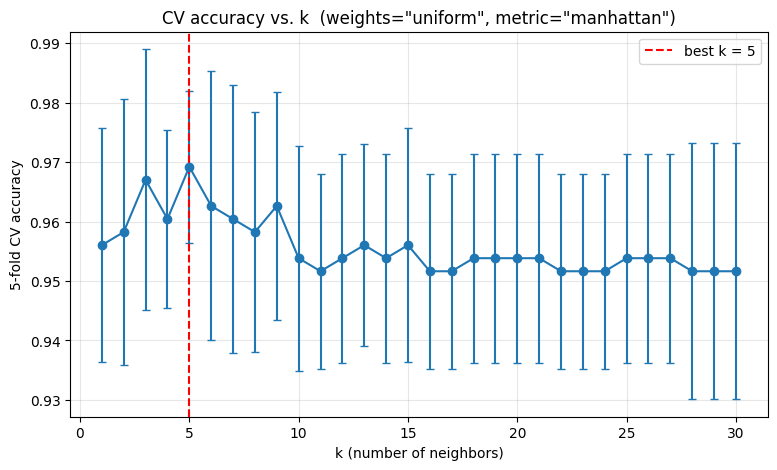

In [10]:
# Show CV accuracy vs k for the best (weights, metric) combo
bw = grid.best_params_['knn__weights']
bm = grid.best_params_['knn__metric']
mask = (cv_results['param_knn__weights'] == bw) & (cv_results['param_knn__metric'] == bm)
subset = cv_results[mask].sort_values('param_knn__n_neighbors')

plt.figure(figsize=(9, 5))
plt.errorbar(subset['param_knn__n_neighbors'], subset['mean_test_score'],
             yerr=subset['std_test_score'], marker='o', capsize=3)
plt.axvline(grid.best_params_['knn__n_neighbors'], color='red', linestyle='--',
            label=f'best k = {grid.best_params_["knn__n_neighbors"]}')
plt.xlabel('k (number of neighbors)')
plt.ylabel('5-fold CV accuracy')
plt.title(f'CV accuracy vs. k  (weights="{bw}", metric="{bm}")')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Full CV Performance Metrics

Since we cannot use the test set, we use `cross_val_predict` to get out-of-fold predictions for every training example — each prediction is made by a model that has never seen that example. These predictions give us honest estimates of accuracy, precision, recall, F1, AUC, and a confusion matrix, all without touching test data.

In [11]:
best_pipe = grid.best_estimator_

# Cross-validated predictions on training data (no leakage — each fold predicts held-out data)
y_cv_pred = cross_val_predict(best_pipe, X_train, y_train, cv=5)
y_cv_prob = cross_val_predict(best_pipe, X_train, y_train, cv=5, method='predict_proba')[:, 1]

print(f'kNN parameters: {grid.best_params_}\n')
print('=== 5-Fold Cross-Validated Metrics (on training data) ===')
print(f'Accuracy:  {accuracy_score(y_train, y_cv_pred):.3f}')
print(f'Precision: {precision_score(y_train, y_cv_pred):.3f}')
print(f'Recall:    {recall_score(y_train, y_cv_pred):.3f}   <-- key metric for cancer screening')
print(f'F1 score:  {f1_score(y_train, y_cv_pred):.3f}')
print(f'AUC:       {roc_auc_score(y_train, y_cv_prob):.3f}')
print(f'\nBaseline (majority class): {baseline_acc:.3f}')

kNN parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 5, 'knn__weights': 'uniform'}

=== 5-Fold Cross-Validated Metrics (on training data) ===
Accuracy:  0.969
Precision: 0.988
Recall:    0.929   <-- key metric for cancer screening
F1 score:  0.958
AUC:       0.985

Baseline (majority class): 0.627


CV Confusion Matrix:
[[283   2]
 [ 12 158]]

  True Negatives  (benign correctly identified):    283
  False Positives (benign flagged as malignant):    2
  False Negatives (malignant missed):               12  <-- worst kind of error
  True Positives  (malignant correctly identified): 158


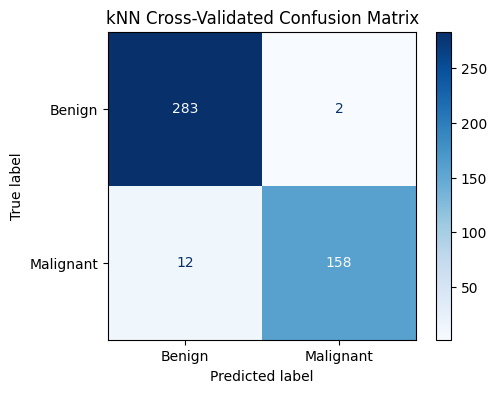

In [12]:
cm = confusion_matrix(y_train, y_cv_pred)
tn, fp, fn, tp = cm.ravel()
print(f'CV Confusion Matrix:\n{cm}\n')
print(f'  True Negatives  (benign correctly identified):    {tn}')
print(f'  False Positives (benign flagged as malignant):    {fp}')
print(f'  False Negatives (malignant missed):               {fn}  <-- worst kind of error')
print(f'  True Positives  (malignant correctly identified): {tp}')

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malignant']).plot(ax=ax, cmap='Blues')
plt.title('kNN Cross-Validated Confusion Matrix')
plt.show()

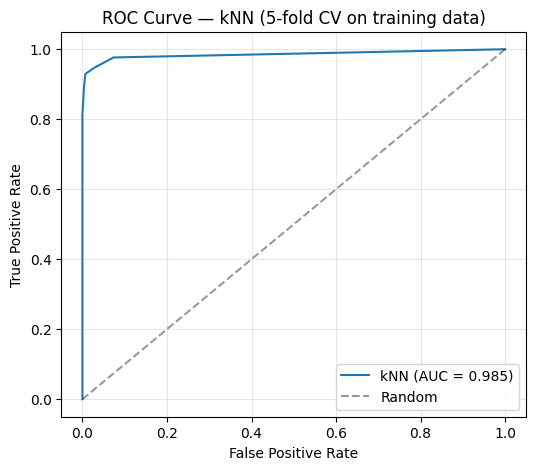

In [13]:
# ROC curve using cross-validated probabilities
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_train, y_cv_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'kNN (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — kNN (5-fold CV on training data)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Discussion

### Beating the baseline
A trivial model that predicts "benign" for every tumor would score ~0.63 accuracy (the class balance in the data). Our kNN achieves ~0.97 CV accuracy — meaningfully better than baseline, and confirms the model is learning real patterns rather than just guessing.

### Overfitting check
The 5-fold CV accuracy across the best hyperparameter combination is stable (small `std_CV_acc` in the top-10 table), and neighbors of k=5 give similar accuracy. This stability suggests the model is not overfitting: performance doesn't crumble when the validation fold changes. The final overfitting check will come when the group's single winning model is evaluated on the held-out test set.

### Why recall matters most here
In cancer screening, a false negative means a patient with a malignant tumor is told they're fine — a potentially fatal error. A false positive means a benign tumor is flagged and the patient undergoes follow-up biopsy — inconvenient but not dangerous. We therefore prioritize **recall** on the malignant class.

### Weaknesses of the kNN approach
- **No feature importance:** kNN uses all 30 features equally at prediction time and gives no coefficients or splits to indicate which features matter. This limits its usefulness for answering the *"which features are most predictive?"* part of our research question — logistic regression and decision trees will be more informative there.
- **Slow at prediction time:** each new prediction requires computing distances to all training points. Not a problem here (455 training tumors), but wouldn't scale to a huge dataset.
- **Sensitive to irrelevant features:** since kNN treats every feature equally in distance calculations, noisy or redundant features can hurt performance. Edward's PCA analysis may address this by producing a lower-dimensional, cleaner feature space to run kNN on.
- **No probability calibration:** kNN's `predict_proba` outputs are just neighbor vote fractions (e.g., 3/5 = 0.60), so they're coarser than logistic regression's smooth probabilities.